# Weather Predictions

In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import Input
from keras.models import Sequential
from keras.models import Model
from keras.layers import Conv1D, Conv2D, Dense, BatchNormalization, Flatten, MaxPooling2D, Activation
from tensorflow.keras.layers import Dense, Dropout, Activation
from keras import utils
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn import metrics
import numpy as np
from keras.models import Sequential
from keras.layers import Conv1D, Conv2D, Dense, BatchNormalization, Flatten, MaxPooling1D
from keras.layers import Dense, Dropout
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import f1_score
from keras import optimizers
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import KFold
import seaborn as sns
import operator
import time
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from numpy import unique
from numpy import reshape
from keras.models import Sequential
from sklearn.model_selection import cross_val_score
from keras.layers import Conv1D, Conv2D, Dense, Dropout, BatchNormalization, Flatten, MaxPooling1D
from keras.layers import Dense, Dropout
#from keras.utils import np_utils
from keras import utils
from keras.optimizers import Adam, SGD, RMSprop, Adadelta, Adagrad, Adamax, Nadam, Ftrl
from keras.callbacks import EarlyStopping, ModelCheckpoint
#from keras.wrappers.scikit_learn import KerasClassifier
from scikeras.wrappers import KerasRegressor
from math import floor
from sklearn.metrics import make_scorer, accuracy_score
from bayes_opt import BayesianOptimization
from sklearn.model_selection import StratifiedKFold
from keras.layers import LeakyReLU
LeakyReLU = LeakyReLU(negative_slope=0.1)
import warnings
warnings.filterwarnings('ignore')
pd.set_option("display.max_columns", None)

In [11]:
#download the weather images and put them in a directory
path = r'C:\Users\isava\OneDrive\Documents\CareerFoundry\MachineLearning\ClimateWins\02 Data\OriginalData\WeatherPhotos\Multi-class Weather Dataset'
folders = os.listdir(path)
print(folders)

['Cloudy', 'Rain', 'Shine', 'Sunrise']


In [13]:
#this will load in the pictures and rescale them to 250x250pixels

datagenerator = ImageDataGenerator(rescale=1/255, validation_split=0.2)
train_generator = datagenerator.flow_from_directory(
    path,
    target_size=(250 , 250),
    batch_size=32,
    subset='training',
)

test_generator = datagenerator.flow_from_directory(
    path,
    target_size=(250 , 250),
    batch_size=32,
    subset='validation',
)

Found 901 images belonging to 4 classes.
Found 224 images belonging to 4 classes.


In [15]:
#this is a CNN to categorize the weather images

inputs = Input(shape=(250, 250, 3))

x = Conv2D(32, (5,5), activation = 'relu')(inputs)
x = MaxPooling2D(3,3)(x)
x = Conv2D(64, (5,5) , activation = 'relu')(x)
x = MaxPooling2D((3,3))(x)
x = Conv2D(128 , (5,5) , activation = 'relu')(x)
x = MaxPooling2D(3,3)(x)
x = Flatten()(x)
x = Dropout(0.5, seed = 5)(x)
x = Dense(128 , activation = 'relu')(x)

outputs = Dense(4, activation = 'softmax')(x)

model:Model = Model(inputs=inputs, outputs=outputs)

In [25]:
#compile and run the model
#how many epochs are required to generate an accurate model?

model.compile(optimizer="Adam", loss="mean_squared_error", metrics=["accuracy"])
model.fit(
    train_generator, 
    epochs = 45, #<----FILL THIS IN!
    steps_per_epoch = train_generator.n // train_generator.batch_size,
    validation_data = test_generator,
    validation_steps = test_generator.n // test_generator.batch_size,
)

Epoch 1/45
28/28 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.8953 - loss: 0.0388 - val_accuracy: 0.8348 - val_loss: 0.0627
Epoch 2/45
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 255ms/step - accuracy: 0.9062 - loss: 0.0397 - val_accuracy: 0.8571 - val_loss: 0.0582
Epoch 3/45
28/28 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.9310 - loss: 0.0251 - val_accuracy: 0.8705 - val_loss: 0.0513
Epoch 4/45
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 254ms/step - accuracy: 0.9375 - loss: 0.0272 - val_accuracy: 0.8839 - val_loss: 0.0411
Epoch 5/45
28/28 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.9367 - loss: 0.0238 - val_accuracy: 0.8393 - val_loss: 0.0665
Epoch 6/45
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 252ms/step - accuracy: 0.9062 - loss: 0.0326 - val_accuracy: 0.8795 - val_loss: 0.0542
Epoch 7/45
28/28 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.9494 - loss: 0.0205 - val_accuracy: 0.8170 - val_loss: 0.0720
Epoch 8/45
28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 385ms/step - accuracy: 0.9688 - loss: 0.0066 - val_accuracy: 0.8527 - 

Converged withing 45 epochs with an accuracy of 98.5% and a small loss of 0.0057. 

In [28]:
results = pd.DataFrame(model.history.history)

<Axes: title={'center': 'Model Loss'}>

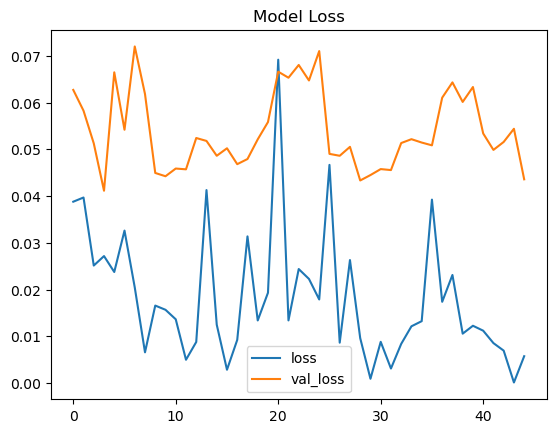

In [30]:
results[['loss','val_loss']].plot(title='Model Loss')
#plt.savefig('./loss.png')

<Axes: title={'center': 'Model Acurracy'}>

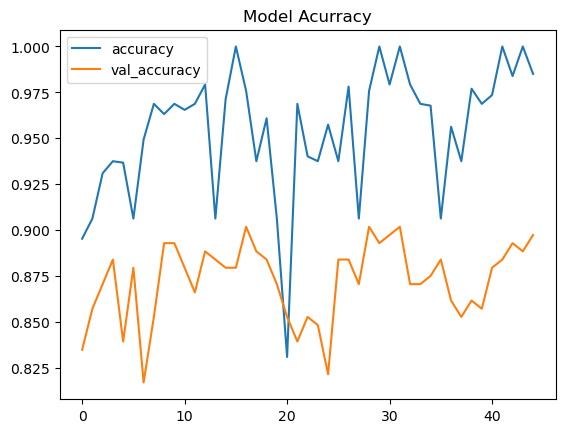

In [32]:
results[['accuracy','val_accuracy']].plot(title='Model Acurracy')
#plt.savefig('./accuracy.png')

In [34]:
# Print the accuracy and loss
print("Accuracy: {}, Val_Accuracy: {}".format(results['accuracy'].iloc[-1], results['val_accuracy'].iloc[-1]))
print("Loss: {}, Val_Loss: {}".format(results['loss'].iloc[-1], results['val_loss'].iloc[-1]))

Accuracy: 0.9850402474403381, Val_Accuracy: 0.8973214030265808
Loss: 0.0057451156899333, Val_Loss: 0.04357165843248367


11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 691ms/step


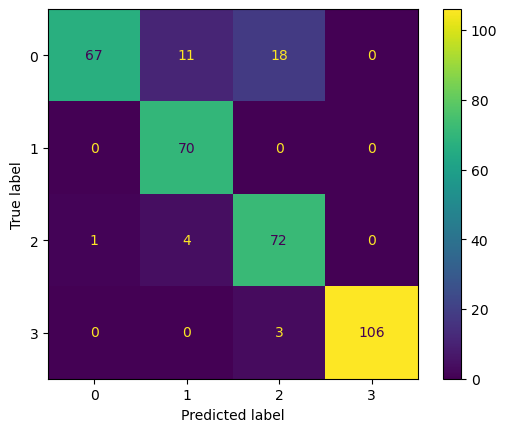

In [36]:
# collect n batches of images and display the confusion matrix for them.

class_names = ['Cloudy', 'Rain', 'Shine', 'Sunrise']
n = 10 #<--you can change the number of batches selected.

image_batch, classes_batch = next(test_generator)

for batch in range(n):
    temp = next(test_generator)
    image_batch = np.concatenate((image_batch, temp[0]))
    classes_batch = np.concatenate((classes_batch, temp[1]))

classes_batch = classes_batch
y_predict = model.predict(image_batch)

#Confusion matrix for training data
cm = confusion_matrix(y_pred = [np.argmax(x) for x in y_predict], y_true = [np.argmax(x) for x in classes_batch])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [56]:
print(metrics.classification_report(y_pred = [np.argmax(x) for x in y_predict], y_true = [np.argmax(x) for x in classes_batch], zero_division = np.nan, target_names = class_names)) #Shape

              precision    recall  f1-score   support

      Cloudy       0.99      0.70      0.82        96
        Rain       0.82      1.00      0.90        70
       Shine       0.77      0.94      0.85        77
     Sunrise       1.00      0.97      0.99       109

    accuracy                           0.89       352
   macro avg       0.90      0.90      0.89       352
weighted avg       0.91      0.89      0.89       352



In [38]:
#This function will display a number of random images as well as the predictions for the type of weather.

def predict_one(model, num_images = None):  
    image_batch, classes_batch = next(test_generator)
    predicted_batch = model.predict(image_batch)
    for k in range(0,image_batch.shape[0] if num_images is None else num_images):
        image = image_batch[k]
        real_class = class_names[np.argmax(classes_batch[k])]
        predicted_class = class_names[np.argmax(predicted_batch[k])]
        value_predicted = predicted_batch[k]
        isTrue = (real_class == predicted_class)
        plt.figure(k)
        plt.title(str("Correct Prediction" if isTrue else "Incorrect Prediction") + ' - class: ' + real_class + ' - ' + 'predicted: ' + predicted_class + str(value_predicted))
        plt.axis('off')
        plt.savefig('./' + real_class + '_' + predicted_class + '_' + str(value_predicted) + '.png')
        plt.imshow(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 839ms/step


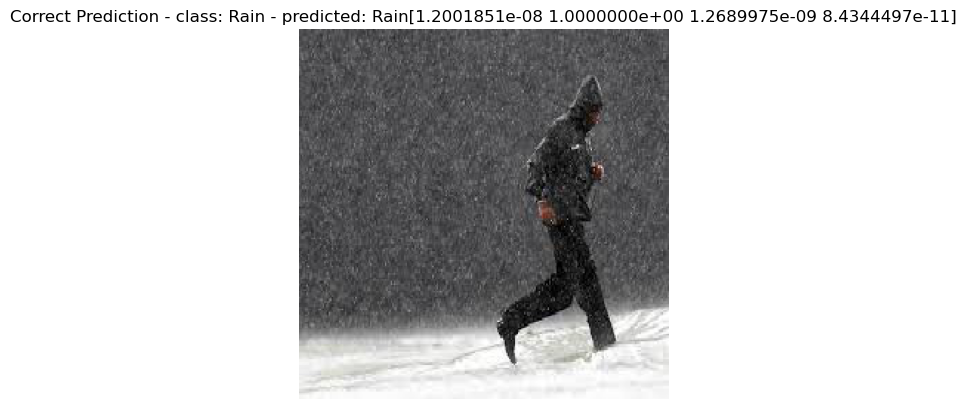

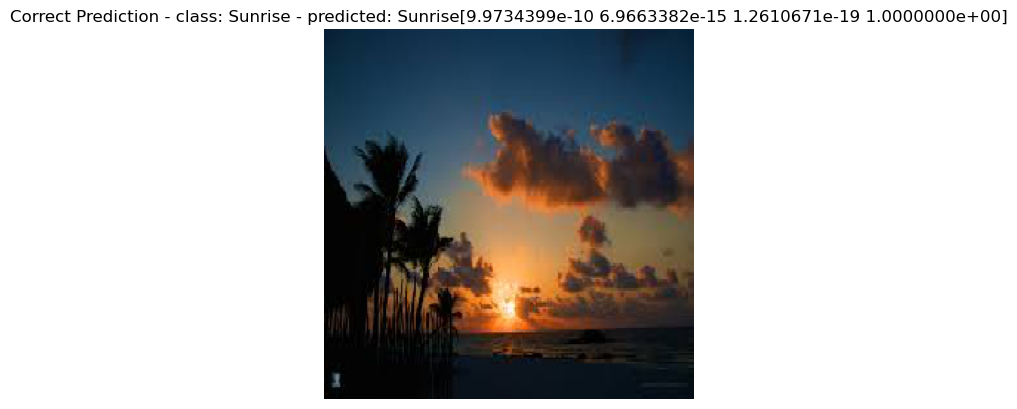

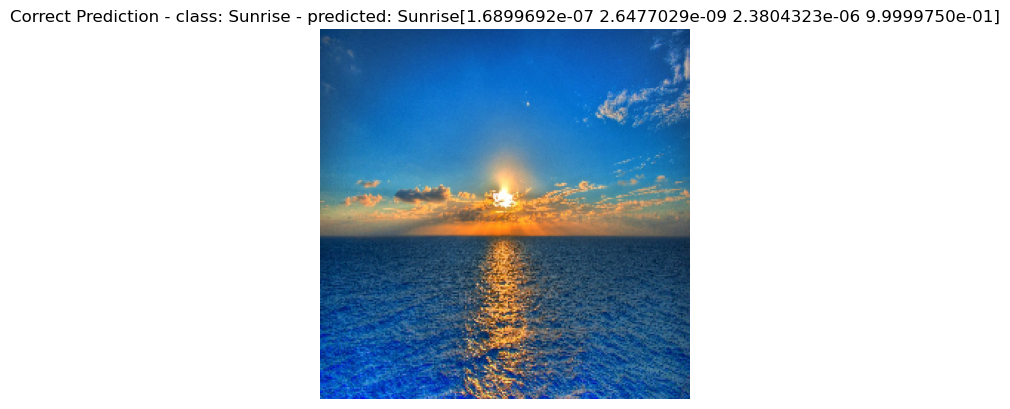

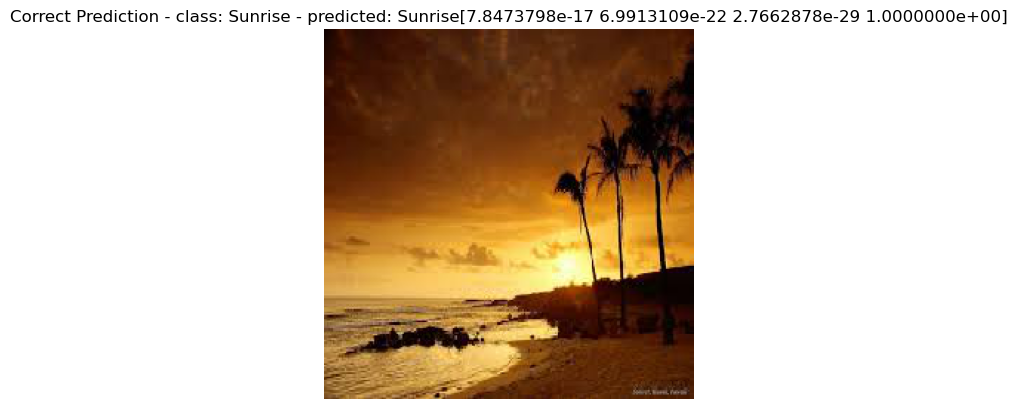

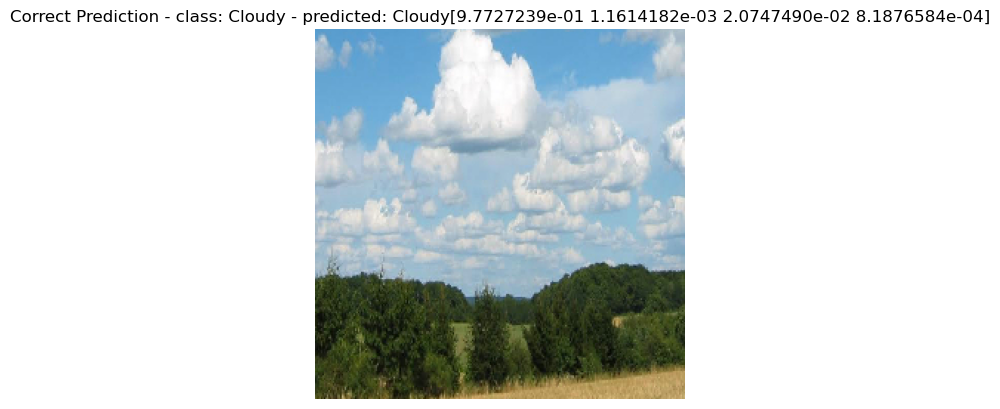

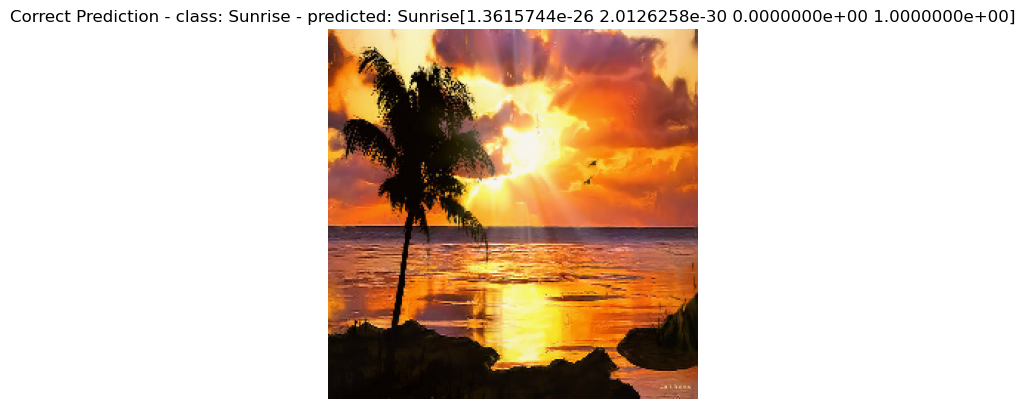

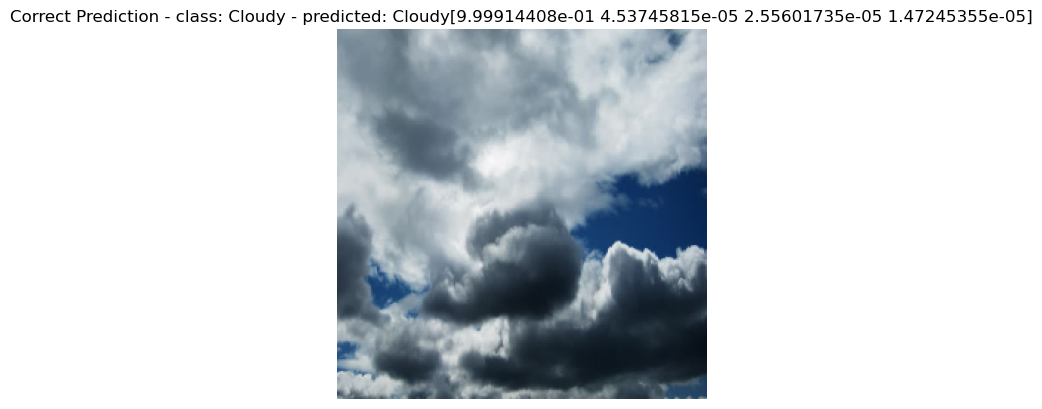

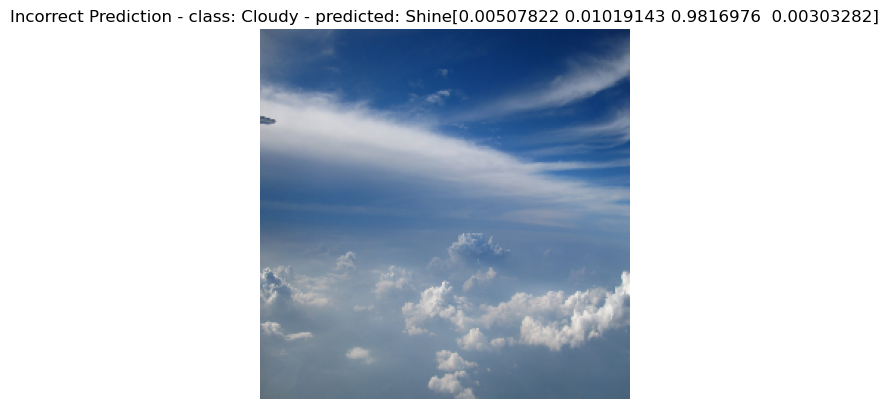

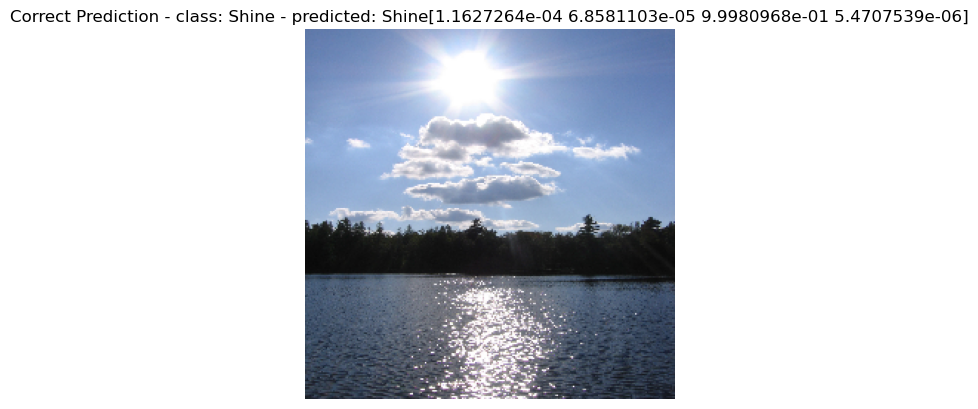

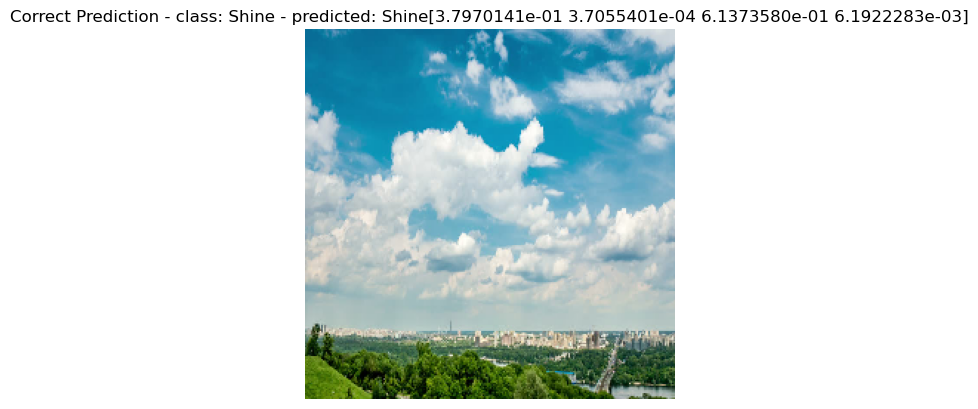

In [60]:
predict_one(model, 10) #<--you can show multiple pictures with this command. Just fill in the number you want to see.

The model struggled more with Shine and Cloudy photos. It did well with rain and sunset photos. In the examples above, a cloudy photo was predicted as shine. Cloudy and Shine photos are both expected to have large peices of white in the photo. This may be one explanation as to why the model struggled more with these classes.

### Weather Prediction

1. Real Time Analysis
   - At each weather station, update photos at a set increment can be taken (say 5 minutes). These photos can enter the GAN model to get a real time update on what the weather looks like now.
   - This can update citizens around the area, alert helicopters of flying conditions and provide interesting information of how weather changes throughout the day.
3. Weather alerts
   - With the use of past photos then future weather for certain days could be predicted.
   - It would be interesting to get an AI created photo of what the day is expected to look like.
   - Alert citizens of bad weather conditions, expected snow days, hurricanes, etc. 
5. Tourist Visits
   - Using photos taken at popular tourist attractions the model can predict ideal times to visit certain attractions.
   - This can be used to alert tourists what to pack (raincoats for rain, shorts for shine, etc.)
   - This can also be used to plan their trips such as going to museums or resturaunts on rainy days, the beach on shine days, and a rooftop bar on days predicted to have a good sunset. 